In [17]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN, fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torchvision.transforms import ToTensor, functional as F
import matplotlib.pyplot as plt
from PIL import Image

In [18]:
class CocoTransform:
    def __call__(self, image, target):
        image = F.to_tensor(image)
        return image, target

In [19]:
def get_coco_dataset(img_dir, ann_file):
    return CocoDetection(
        root=img_dir,
        annFile=ann_file,
        transforms=CocoTransform()
    )

# Update paths to point to the actual data location
train_dataset = get_coco_dataset(
    img_dir='output/split_data/train',
    ann_file='output/split_data/train/annotations.json'
)

# Use test split as validation
val_dataset = get_coco_dataset(
    img_dir='output/split_data/test',
    ann_file='output/split_data/test/annotations.json'
)

batch_size = 4
shuffle = True
collate_fn = lambda x: tuple(zip(*x))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [20]:
# Verify dataset loading
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

# Check a sample from the dataset
sample_image, sample_target = train_dataset[0]
print(f"\nSample image shape: {sample_image.shape}")
print(f"Sample target: {sample_target}")
print(f"Number of annotations in sample: {len(sample_target)}")

# Verify categories
import json
with open('output/split_data/train/annotations.json', 'r') as f:
    coco_data = json.load(f)
    
categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
print(f"\nNumber of categories: {len(categories)}")
print(f"Categories: {sorted(categories.items())}")
print(f"\nDataset is ready for training!")


Train dataset size: 2895
Validation dataset size: 1241

Sample image shape: torch.Size([3, 80, 575])
Sample target: [{'id': 1, 'image_id': 1, 'category_id': 33, 'bbox': [138, 36, 30, 26], 'area': 780, 'iscrowd': 0, 'segmentation': []}, {'id': 2, 'image_id': 1, 'category_id': 31, 'bbox': [209, 39, 18, 22], 'area': 396, 'iscrowd': 0, 'segmentation': []}, {'id': 3, 'image_id': 1, 'category_id': 6, 'bbox': [271, 34, 17, 27], 'area': 459, 'iscrowd': 0, 'segmentation': []}, {'id': 4, 'image_id': 1, 'category_id': 22, 'bbox': [330, 31, 4, 30], 'area': 120, 'iscrowd': 0, 'segmentation': []}, {'id': 5, 'image_id': 1, 'category_id': 34, 'bbox': [376, 39, 17, 22], 'area': 374, 'iscrowd': 0, 'segmentation': []}]
Number of annotations in sample: 5

Number of categories: 36
Categories: [(1, '0'), (2, '1'), (3, '2'), (4, '3'), (5, '4'), (6, '5'), (7, '6'), (8, '7'), (9, '8'), (10, '9'), (11, 'a'), (12, 'b'), (13, 'c'), (14, 'd'), (15, 'e'), (16, 'f'), (17, 'g'), (18, 'h'), (19, 'i'), (20, 'j'), (21, 

In [21]:
def get_model(num_classes):
    model = fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [22]:
num_classes = 36 + 1  # 36 characters + background
model = get_model(num_classes)

In [23]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.backends.cudnn.version())
print(torch.cuda.is_available())
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# Hyperparameters
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
num_epochs = 10

2.5.1+cu121
12.1
90100
True


In [24]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for batch_idx, (images, targets) in enumerate(data_loader):
        images = [img.to(device) for img in images]

        processed_targets = []
        valid_images = []
        
        for i, target in enumerate(targets):
            boxes = []
            labels = []

            for obj in target:
                bbox = obj["bbox"]
                x, y, w, h = bbox

                if w > 0 and h > 0:
                    boxes.append([x, y, x + w, y + h])
                    labels.append(obj["category_id"])

            # Only process if there are valid boxes
            if boxes:
                processed_target = {
                    "boxes": torch.tensor(boxes, dtype=torch.float32).to(device),
                    "labels": torch.tensor(labels, dtype=torch.int64).to(device)
                }
                processed_targets.append(processed_target)
                valid_images.append(images[i])

        # Skip batch if no valid images
        if not processed_targets:
            continue
            
        images = valid_images

        # Zero gradients before forward pass
        optimizer.zero_grad()
        
        # Forward pass
        loss_dict = model(images, processed_targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backward pass
        losses.backward()
        optimizer.step()
        
        total_loss += losses.item()
        num_batches += 1
        
        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch [{batch_idx + 1}/{len(data_loader)}], Loss: {losses.item():.4f}")
    
    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    print(f"Epoch [{epoch + 1}], Average Loss: {avg_loss:.4f}")
    return avg_loss
    

In [25]:
num_epochs = 20

# Create outputs directory if it doesn't exist
import os
os.makedirs('outputs', exist_ok=True)

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Training Epoch {epoch + 1}/{num_epochs}")
    print(f"{'='*50}")
    
    train_one_epoch(model, optimizer, train_loader, device, epoch)
    lr_scheduler.step()

    model_path = f"outputs/model_epoch_{epoch + 1}.pth"
    torch.save(model.state_dict(), model_path)

    print(f"Model saved to {model_path}\n")



Training Epoch 1/20


KeyboardInterrupt: 

C:\Users\wesle\AppData\Local\Temp\ipykernel_14532\1807814720.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


NMS threshold (IoU): 0.05 (lower = stricter overlap suppression)
Score threshold: 0.5 (higher = stricter confidence filtering)

These settings will:
  - Suppress overlapping boxes with IoU > 0.05
  - Keep only detections with confidence > 0.5
[{'boxes': tensor([[155.9553,  30.4187, 172.9201,  52.1752],
        [124.2642,  29.7852, 142.1730,  52.3517],
        [ 93.9335,  30.0249, 113.6029,  51.7949],
        [ 63.5190,  29.8308,  83.5433,  52.1752],
        [ 93.5660,  30.0322, 113.3265,  51.9670],
        [ 63.5608,  29.8399,  83.7055,  52.0809]], device='cuda:0'), 'labels': tensor([21,  3,  1, 25, 25,  1], device='cuda:0'), 'scores': tensor([0.9997, 0.9979, 0.5759, 0.5740, 0.5623, 0.5493], device='cuda:0')}]


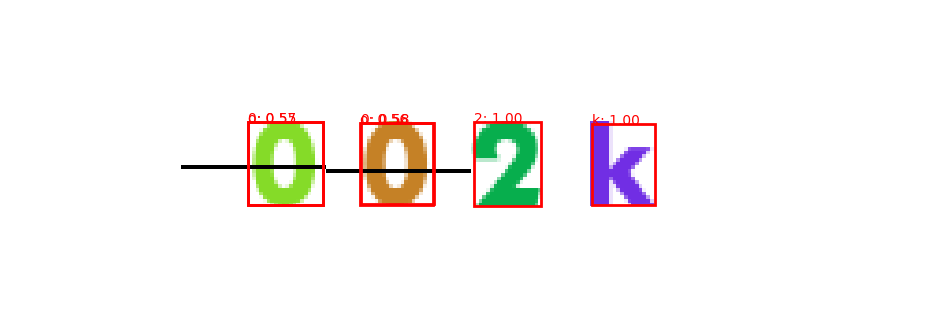

[{'boxes': tensor([[333.9572,  26.4601, 350.4375,  52.8721],
        [271.7326,  26.4941, 284.4512,  52.4017],
        [530.5526,  25.7527, 547.5270,  51.8171],
        [463.5647,  25.7508, 481.3939,  53.0486],
        [400.4039,  25.9598, 416.6101,  52.6616],
        [144.2363,  25.4447, 156.0228,  52.1156],
        [208.0482,  26.1464, 220.2029,  52.3080],
        [207.8655,  26.1078, 219.9103,  52.6041]], device='cuda:0'), 'labels': tensor([11,  7, 32, 31, 10, 25, 25,  1], device='cuda:0'), 'scores': tensor([0.9913, 0.9888, 0.9294, 0.8881, 0.8264, 0.6276, 0.5414, 0.5289],
       device='cuda:0')}]


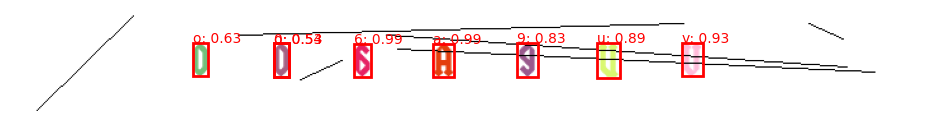

[{'boxes': tensor([[182.0749,  34.3237, 188.2675,  39.6784],
        [180.3399,  34.1579, 187.9928,  41.9043]], device='cuda:0'), 'labels': tensor([28, 16], device='cuda:0'), 'scores': tensor([0.5872, 0.5124], device='cuda:0')}]


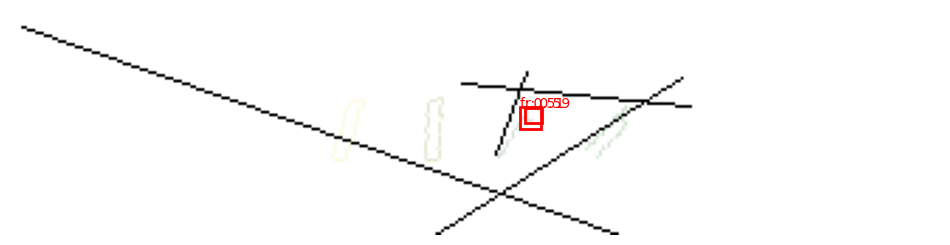

[{'boxes': tensor([[206.0732,  27.8431, 229.8053,  54.8943],
        [259.4260,  28.0697, 289.1921,  56.0793],
        [317.8156,  27.6589, 324.4077,  55.2864],
        [101.9464,  28.3227, 123.6302,  55.2083],
        [153.9124,  28.2489, 175.7965,  54.8944],
        [154.0620,  27.9556, 175.6646,  54.7058]], device='cuda:0'), 'labels': tensor([18, 11, 19,  1,  1, 25], device='cuda:0'), 'scores': tensor([0.9996, 0.9989, 0.7879, 0.5990, 0.5466, 0.5322], device='cuda:0')}]


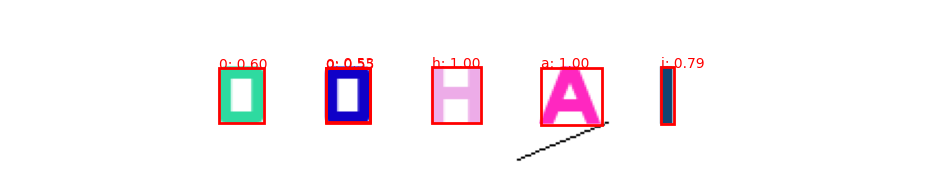

[{'boxes': tensor([[253.3193,  27.2646, 272.2776,  59.3146],
        [285.9397,  25.0100, 305.1018,  62.6763],
        [196.5903,  27.3376, 212.8268,  59.9650],
        [161.9109,  23.0689, 181.7737,  59.9858],
        [320.3744,  21.6525, 334.5653,  60.3731],
        [128.7328,  27.1952, 148.1212,  59.9487],
        [ 95.7538,  25.5059, 114.5672,  61.4585],
        [227.9971,  25.1456, 238.0934,  63.0859]], device='cuda:0'), 'labels': tensor([ 4, 24, 17, 18,  8,  1,  1, 19], device='cuda:0'), 'scores': tensor([0.9975, 0.9940, 0.9759, 0.9634, 0.9587, 0.7242, 0.6723, 0.6036],
       device='cuda:0')}]


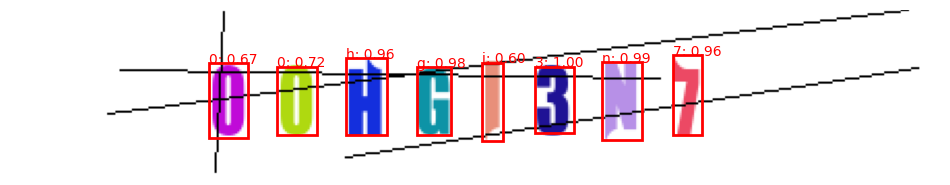

[{'boxes': tensor([[376.2596,  29.6750, 392.2312,  52.8304],
        [323.9658,  32.6435, 339.9762,  54.9097],
        [265.1863,  35.9202, 276.9859,  51.0325],
        [153.8541,  29.2190, 175.7835,  54.4344],
        [210.0579,  30.6003, 232.1746,  53.5641]], device='cuda:0'), 'labels': tensor([ 8,  5, 25, 25, 25], device='cuda:0'), 'scores': tensor([0.9980, 0.9604, 0.6926, 0.6330, 0.5474], device='cuda:0')}]


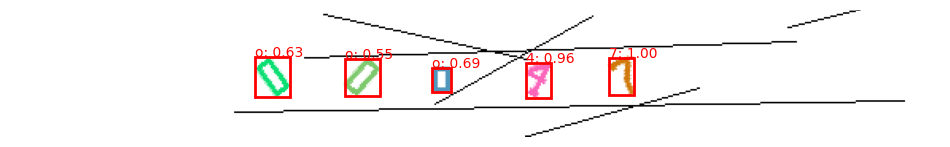

[{'boxes': tensor([[153.6848,  29.4661, 184.7432,  58.8387],
        [220.1816,  28.7373, 243.8736,  54.2585],
        [195.0660,  30.3531, 215.7700,  52.3113],
        [220.1785,  28.5748, 243.4957,  54.2954],
        [ 79.4749,  33.5251, 105.4472,  55.1056],
        [118.8689,  29.0005, 138.1558,  57.0451],
        [118.9588,  29.4185, 138.0355,  57.6656],
        [ 79.8702,  33.2182, 106.2886,  55.3269]], device='cuda:0'), 'labels': tensor([33, 29, 19,  6, 25,  1, 25,  1], device='cuda:0'), 'scores': tensor([0.9871, 0.7306, 0.7231, 0.6912, 0.6567, 0.5429, 0.5251, 0.5143],
       device='cuda:0')}]


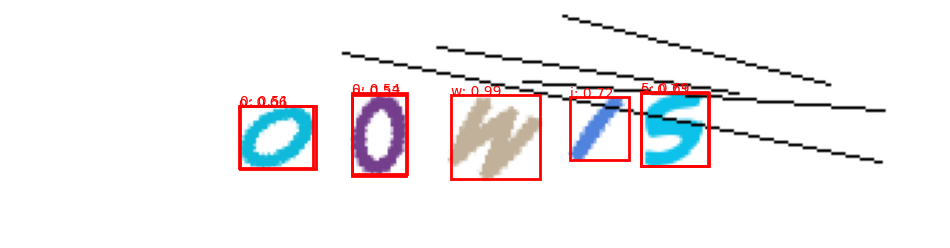

[{'boxes': tensor([[438.3628,  33.3502, 463.1727,  62.8877],
        [366.7160,  20.9914, 391.8491,  60.7845],
        [226.0422,  28.9786, 250.1426,  64.1137],
        [580.1635,  34.0423, 603.3299,  61.7882],
        [509.8729,  20.6283, 533.5875,  61.0430],
        [169.4075,  21.3865, 181.0480,  60.6682],
        [ 99.0190,  20.9459, 121.2832,  62.3675],
        [296.4630,  33.2775, 320.6459,  61.4088],
        [510.2601,  21.0577, 533.0309,  60.6577],
        [ 98.6473,  20.7706, 121.8549,  62.1318]], device='cuda:0'), 'labels': tensor([28, 21, 29,  6, 14, 19,  1, 25,  1, 14], device='cuda:0'), 'scores': tensor([0.9977, 0.9947, 0.9316, 0.8692, 0.6995, 0.5833, 0.5736, 0.5352, 0.5245,
        0.5113], device='cuda:0')}]


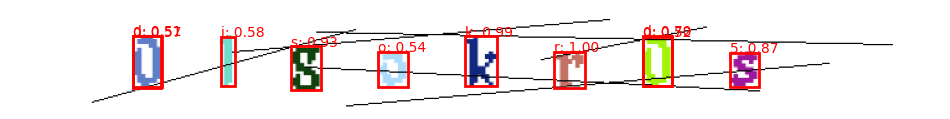

[{'boxes': tensor([[421.7956,  24.4717, 447.8021,  54.6783],
        [277.5927,  23.3898, 296.1566,  55.0359],
        [343.5049,  24.0548, 371.0743,  56.1648],
        [219.9879,  24.4275, 229.8725,  55.1804],
        [154.2092,  25.5350, 172.0418,  54.8746]], device='cuda:0'), 'labels': tensor([23, 18, 23,  2,  1], device='cuda:0'), 'scores': tensor([0.9993, 0.9955, 0.9923, 0.9222, 0.7281], device='cuda:0')}]


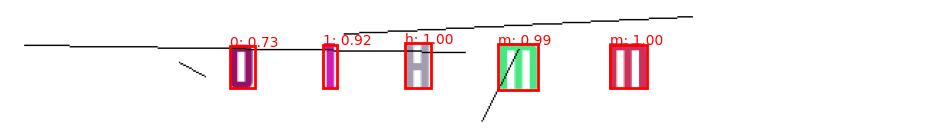

KeyboardInterrupt: 

In [ ]:
# Load trained model
import numpy as np  # For post-processing overlapping boxes

model_path = "outputs/model_epoch_10.pth"
model = get_model(num_classes)
model.load_state_dict(torch.load(model_path))
model.to(device)

# Test the model
model.eval()

# Tune NMS and confidence thresholds for inference
# ================================================
# These settings reduce duplicate boxes by:
#   1. More aggressively suppressing overlapping boxes (lower NMS threshold)
#   2. Filtering out low-confidence detections (higher score threshold)
#
# NMS Threshold (IoU): Controls overlap suppression
#   - Default: 0.5
#   - Lower values = more aggressive suppression (boxes with IoU > threshold are suppressed)
#   - Current: 0.2 (stricter than default)
#
# Score Threshold: Minimum confidence for detections
#   - Default: 0.05
#   - Higher values = only high-confidence detections kept
#   - Current: 0.5 (stricter than default)
# ================================================
NMS_THRESHOLD = 0.05  # IoU threshold for NMS (lower = stricter, reduces duplicates)
SCORE_THRESHOLD = 0.5  # Confidence score threshold (higher = stricter, filters weak detections)

model.roi_heads.nms_thresh = NMS_THRESHOLD
model.roi_heads.score_thresh = SCORE_THRESHOLD
print(f"NMS threshold (IoU): {model.roi_heads.nms_thresh} (lower = stricter overlap suppression)")
print(f"Score threshold: {model.roi_heads.score_thresh} (higher = stricter confidence filtering)")
print(f"\nThese settings will:")
print(f"  - Suppress overlapping boxes with IoU > {NMS_THRESHOLD}")
print(f"  - Keep only detections with confidence > {SCORE_THRESHOLD}")

def prepare_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = F.to_tensor(image).unsqueeze(0)
    return image_tensor.to(device)

# Load category mapping from the annotations file
import json
with open('output/split_data/train/annotations.json', 'r') as f:
    coco_data = json.load(f)
    
# Create category mapping: category_id -> name
COCO_CLASSES = {cat['id']: cat['name'] for cat in coco_data['categories']}

def get_class_name(class_id):
    return COCO_CLASSES.get(class_id, f"unknown_{class_id}")

def calculate_iou(box1, box2):
    """
    Calculate Intersection over Union (IoU) between two bounding boxes.
    
    Args:
        box1: [x1, y1, x2, y2]
        box2: [x1, y1, x2, y2]
    
    Returns:
        IoU value between 0 and 1
    """
    # Calculate intersection area
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    
    # Intersection coordinates
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)
    
    # Check if there's an intersection
    if inter_x_max < inter_x_min or inter_y_max < inter_y_min:
        return 0.0
    
    # Calculate intersection area
    inter_area = (inter_x_max - inter_x_min) * (inter_y_max - inter_y_min)
    
    # Calculate union area
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    union_area = box1_area + box2_area - inter_area
    
    # Avoid division by zero
    if union_area == 0:
        return 0.0
    
    # Calculate IoU
    iou = inter_area / union_area
    return iou

def remove_overlapping_boxes(prediction, iou_threshold=0.5):
    """
    Remove overlapping bounding boxes. If boxes overlap by more than iou_threshold,
    keep only the one with the highest score.
    
    Args:
        prediction: Dictionary with 'boxes', 'labels', 'scores' tensors
        iou_threshold: IoU threshold above which boxes are considered overlapping (default: 0.5)
    
    Returns:
        Filtered prediction dictionary with overlapping boxes removed
    """
    boxes = prediction[0]["boxes"].cpu().numpy()
    labels = prediction[0]["labels"].cpu().numpy()
    scores = prediction[0]["scores"].cpu().numpy()
    
    # Sort by score (descending) so we process higher-scoring boxes first
    sorted_indices = np.argsort(scores)[::-1]
    
    keep_indices = []
    
    for i in sorted_indices:
        current_box = boxes[i]
        should_keep = True
        
        # Check if this box overlaps significantly with any already-kept box
        for kept_idx in keep_indices:
            kept_box = boxes[kept_idx]
            iou = calculate_iou(current_box, kept_box)
            
            # If IoU > threshold, suppress this box (it has lower score since we're sorted)
            if iou > iou_threshold:
                should_keep = False
                break
        
        # Only keep if it doesn't overlap significantly with any kept box
        if should_keep:
            keep_indices.append(i)
    
    # Sort keep_indices to maintain original order
    keep_indices = sorted(keep_indices)
    
    # Filter predictions and preserve device placement
    original_device = prediction[0]["boxes"].device
    filtered_boxes = torch.tensor(boxes[keep_indices], dtype=torch.float32)
    filtered_labels = torch.tensor(labels[keep_indices], dtype=torch.int64)
    filtered_scores = torch.tensor(scores[keep_indices], dtype=torch.float32)
    
    # Return in the same format as input
    filtered_prediction = [{
        "boxes": filtered_boxes,
        "labels": filtered_labels,
        "scores": filtered_scores
    }]
    
    if len(keep_indices) < len(boxes):
        print(f"Removed {len(boxes) - len(keep_indices)} overlapping boxes (IoU > {iou_threshold})")
    
    return filtered_prediction

def draw_boxes(image, prediction, fig_size=(10, 10), vis_threshold=None):
    boxes = prediction[0]["boxes"].cpu().numpy()
    labels = prediction[0]["labels"].cpu().numpy()
    scores = prediction[0]["scores"].cpu().numpy()

    # Use model's score threshold for visualization if not specified
    # Since model already filters by score_thresh, we can show all returned detections
    threshold = vis_threshold if vis_threshold is not None else model.roi_heads.score_thresh

    plt.figure(figsize=fig_size)

    for box, label, score in zip(boxes, labels, scores):
        if score > threshold:
            x_min, y_min, x_max, y_max = box
            class_name = get_class_name(label)
            plt.imshow(image)
            plt.gca().add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, fill=False, edgecolor="red", linewidth=2, facecolor="none"))
            plt.text(x_min, y_min, f"{class_name}: {score:.2f}", color="red")

    
    plt.axis("off")
    plt.show()

# Post-processing: Remove overlapping boxes
# If boxes overlap by more than 0.5 IoU, keep only the one with highest score
OVERLAP_IOU_THRESHOLD = 0.5  # IoU threshold for removing overlapping boxes

# Use relative path or raw string for Windows paths
test_dir = '../data/train'
for image in os.listdir(test_dir):
    if image.endswith('.png'):  # Only process image files
        image_path = os.path.join(test_dir, image)
        image_tensor = prepare_image(image_path)

        with torch.no_grad():
            prediction = model(image_tensor)
        
        # Remove overlapping boxes (IoU > 0.5), keeping the highest score
        prediction = remove_overlapping_boxes(prediction, iou_threshold=OVERLAP_IOU_THRESHOLD)
        
        draw_boxes(Image.open(image_path), prediction, fig_size=(12, 10))
